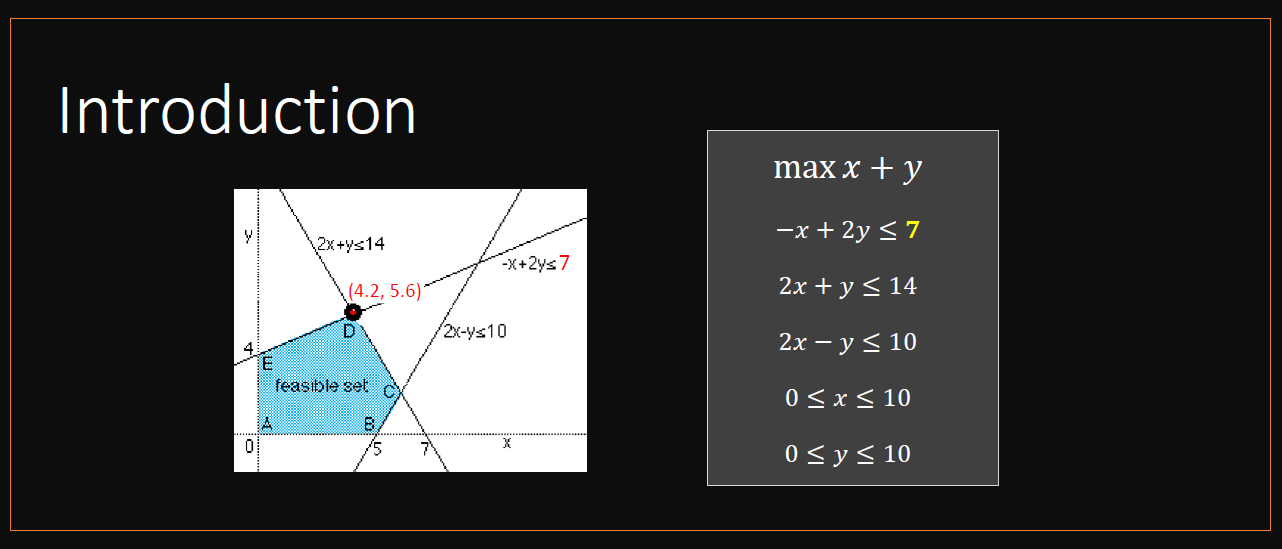

ex_MILP_pyomo

In [1]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

setI = [1,2,3,4]
setJ = [1,2,3,4,5,6,7,8,9,10]
model.z = pyo.Var(setI, setJ, bounds=(0,None))
model.Const_UB_x = pyo.ConstraintList()
for i in setI:
    for j in setJ:
        model.Const_UB_x.add(model.z[i,j] <= 100)
        
        
# 限制 x 是整數
model.x = pyo.Var(within=Integers, bounds=(0,10))
model.y = pyo.Var(bounds=(0,10))
x = model.x
y = model.y

model.C1 = pyo.Constraint(expr= -x+2*y<=7)
model.C2 = pyo.Constraint(expr= 2*x+y<=14)
model.C3 = pyo.Constraint(expr= 2*x-y<=10)

model.obj = pyo.Objective(expr= x+y, sense=maximize)

opt = SolverFactory('gurobi')
opt.solve(model)

model.pprint()

x_value = pyo.value(x)
y_value = pyo.value(y)

print('\n---------------------------------------------------------------------')
print('x=',x_value)
print('y=',y_value)

3 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   4.0 :    10 : False : False : Integers
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   5.5 :    10 : False : False :  Reals
    z : Size=40, Index={1, 2, 3, 4}*{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
        Key     : Lower : Value : Upper : Fixed : Stale : Domain
         (1, 1) :     0 :   0.0 :  None : False : False :  Reals
         (1, 2) :     0 :   0.0 :  None : False : False :  Reals
         (1, 3) :     0 :   0.0 :  None : False : False :  Reals
         (1, 4) :     0 :   0.0 :  None : False : False :  Reals
         (1, 5) :     0 :   0.0 :  None : False : False :  Reals
         (1, 6) :     0 :   0.0 :  None : False : False :  Reals
         (1, 7) :     0 :   0.0 :  None : False : False :  Reals
         (1, 8) :     0 :   0.0 :  None : False : False :  Reals
         (1, 9) :     0 

ex_MILP_ortools

In [2]:
from ortools.linear_solver import pywraplp

# CBC 才能處理混合整數規劃問題
solver = pywraplp.Solver.CreateSolver('CBC')

x = solver.IntVar(0,10,'x')
y = solver.NumVar(0,10,'y')

solver.Add(-x+2*y<=7)
solver.Add(2*x+y<=14)
solver.Add(2*x-y<=10)

solver.Maximize(x+y)

results = solver.Solve()

if results==pywraplp.Solver.OPTIMAL: print('Optimal Found')

print('x:', x.solution_value())
print('y:', y.solution_value())

Optimal Found
x: 4.0
y: 5.5


ex_MILP_scip

In [3]:
from pyscipopt import Model

model = Model('exemplo')

x = model.addVar('x', vtype='INTEGER')
y = model.addVar('y')

model.setObjective(x+y, sense='maximize')

model.addCons(-x+2*y<=7)
model.addCons(2*x+y<=14)
model.addCons(2*x-y<=10)

model.optimize()

sol = model.getBestSol()

print('x=',sol[x])
print('y=',sol[y])

x= 4.0
y= 5.5


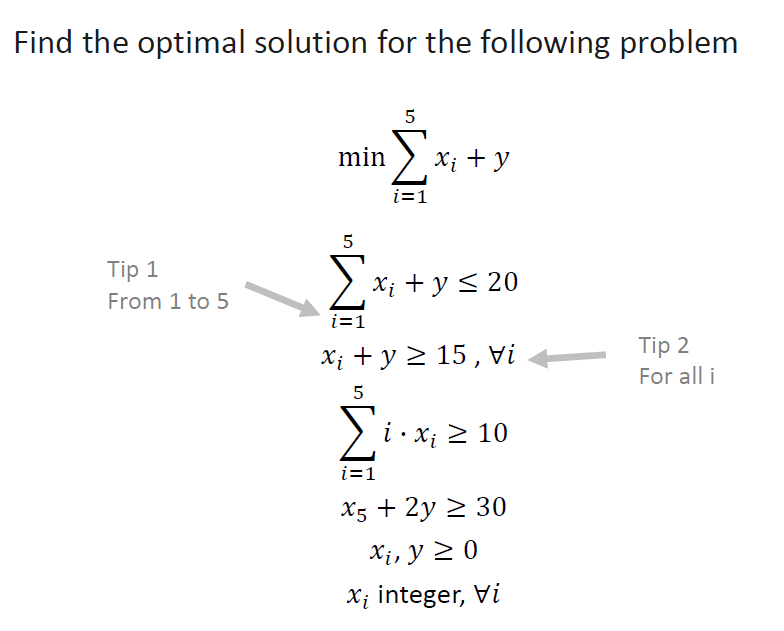

In [4]:
import time, numpy as np
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(range(1,6), within=Integers, bounds=(0,None))
model.y = pyo.Var(bounds=(0,None))
x = model.x
y = model.y

model.C1 = pyo.Constraint(expr = sum([x[i] for i in range(1,6)])+y<=20)
model.C2 = pyo.ConstraintList()
for i in range(1,6):
    model.C2.add(expr = x[i]+y>=15)
model.C3 = pyo.Constraint(expr = sum([i*x[i] for i in range(1,6)]) >= 10)
model.C4 = pyo.Constraint(expr = x[5]+2*y >= 30)

model.obj = pyo.Objective(expr = sum([x[i] for i in range(1,6)])+y, sense=minimize)

begin = time.time()
opt = SolverFactory('gurobi')
opt.solve(model)

deltaT = time.time() - begin

model.pprint()

print('Time =', np.round(deltaT,2))

for i in range(1,6):
    print('x[%i] = %i' % (i, pyo.value(x[i])))
print('y = %.2f' % pyo.value(y))
print('Obj = ', pyo.value(model.obj))

2 Var Declarations
    x : Size=5, Index={1, 2, 3, 4, 5}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :     0 :   0.0 :  None : False : False : Integers
          2 :     0 :  -0.0 :  None : False : False : Integers
          3 :     0 :  -0.0 :  None : False : False : Integers
          4 :     0 :  -0.0 :  None : False : False : Integers
          5 :     0 :   2.0 :  None : False : False : Integers
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  15.0 :  None : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : minimize : x[1] + x[2] + x[3] + x[4] + x[5] + y

4 Constraint Declarations
    C1 : Size=1, Index=None, Active=True
        Key  : Lower : Body                                 : Upper : Active
        None :  -Inf : x[1] + x[2] + x[3] + x[4] + x[5] + y :  20.0 :   True
    C2 :